# 🚀 Day 2: Linear Regression — Training, Coefficients & Evaluation

---

## 🎯 Objectives

- ✅ Train a **linear regression model** and generate predictions  
- ✅ Interpret **coefficients** and the **intercept**  
- ✅ Evaluate with **MAE, RMSE, and R²**  
- ✅ Compare against a **baseline model**  





In [99]:


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X, Y = housing.data, housing.target
features = housing.feature_names

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (16512, 8)
X_test shape: (4128, 8)
Y_train shape: (16512,)
Y_test shape: (4128,)



## 📚 2.1 What Linear Regression Is

Linear regression fits the **best line** through data points to predict a continuous outcome.  
It minimizes the error between predicted and actual values using the **least squares method**.


In [100]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)
predictions = model.predict(X_test)
print(predictions)

[0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]



## ⚖️ 2.2 Coefficients & Intercept

- **Coefficient (slope)**: how much the target changes when a feature increases by 1 unit  
- **Intercept (bias)**: the predicted value when all features are 0  

---


In [101]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept: -37.02327770606397


## 📊 2.3 Evaluation Metrics

| **Metric** | **Meaning** | **Goal** |
|:---:|:---|:---:|
| MAE | Average absolute error | Lower = better |
| RMSE | Penalizes large errors | Lower = better |
| R² | Fraction of variance explained | Closer to 1 = better |

---

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(Y_test, predictions)
rmse = np.sqrt(mean_squared_error(Y_test, predictions))
r2 = r2_score(Y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.5332001304956989
RMSE: 0.7455813830127751
R²: 0.5757877060324521


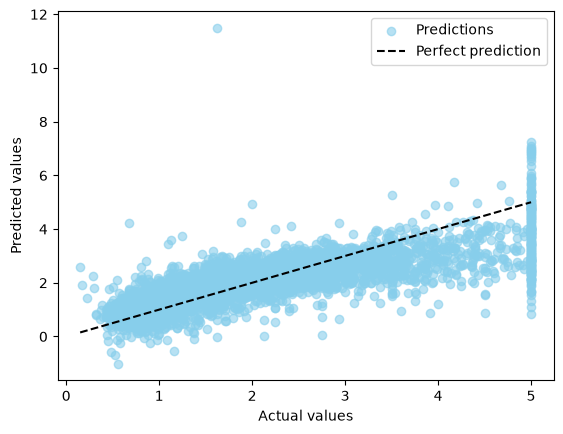

In [103]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, predictions, color="skyblue", alpha=0.6, label="Predictions")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],
         color="black", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.legend()
plt.show()

## 🧪 Hands-On Lab: Regression in Action

> *"A model is only as good as the baseline it beats."*

---

### 🎯 Lab Objectives

By the end of this lab, you will:

- ✅ Train a `LinearRegression` model on a dataset (e.g., house prices)  
- ✅ Report coefficients and identify the strongest feature  
- ✅ Evaluate with MAE, RMSE, and R²  
- ✅ Compare against a **baseline model** (predicting the mean)  
- ✅ Document your interpretation in Markdown  

---

### 🌱 Load Dataset and Split

We begin by loading a dataset and splitting it into training and testing sets.

In [104]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
x, y = diabetes.data, diabetes.target
feature = diabetes.feature_names

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


### ⚙️ Step 1: Train Linear Regression Model
We train a LinearRegression model on the training set and generate predictions.

In [105]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print("Predictions:", predictions[:10])

Predictions: [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


### 🔍step2: Inspected coefficients and intercept  
we generate predictions on the test set and inspect the **coefficients** and **intercept** to understand how each feature influences the target.

In [106]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
import pandas as pd

coef_table= pd.DataFrame({
    "feature": feature,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

print(coef_table)


Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Intercept: 151.34560453985995
  feature  coefficient
4      s1  -931.488846
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902
1     sex  -241.964362
6      s3   163.419983
9      s6    48.670657
0     age    37.904021


### 📊 Step 3: Evaluate Model Performance
We calculate **MAE**, **RMSE**, and **R²** to measure accuracy.

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R²:", r2)


Mean Absolute Error: 42.79409467959994
Root Mean Squared Error: 53.85344583676592
R²: 0.4526027629719197


### 🛡️ Step 4: Baseline Comparison
We compare against a baseline model that always predicts the mean of y_train.

In [108]:

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)
print("Baseline RMSE:", baseline_rmse)

RMSE: 53.85344583676592
Baseline RMSE: 73.22249283682244



The model’s RMSE of 53.85 is substantially lower than the baseline’s
73.22, representing about a 26% reduction in error.
This confirms that the regression model has captured a real relationship
between the features and disease progression, rather than just noise.
